In [51]:
#Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px


In [52]:
#CELL 2 — Load Dataset
df=pd.read_csv("pizza_sales.csv")
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


##METADATA OF THIS DATA 

In [54]:
#CELL 3 — Dataset Shape
print("The metadata of the dataset",df.shape)

The metadata of the dataset (48620, 12)


In [55]:
print("The number of rows in this is ",df.shape[0])

The number of rows in this is  48620


In [56]:
#CELL 4 — Column Names
print("The number of columns in this is ",df.shape[1])

The number of columns in this is  12


In [57]:
print(df.columns)

Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')


In [58]:
#CELL 5 — Dataset Info
df.info

<bound method DataFrame.info of        pizza_id  order_id  pizza_name_id  quantity  order_date order_time  \
0             1         1     hawaiian_m         1  01-01-2015   11:38:36   
1             2         2  classic_dlx_m         1  01-01-2015   11:57:40   
2             3         2  five_cheese_l         1  01-01-2015   11:57:40   
3             4         2    ital_supr_l         1  01-01-2015   11:57:40   
4             5         2     mexicana_m         1  01-01-2015   11:57:40   
...         ...       ...            ...       ...         ...        ...   
48615     48616     21348  ckn_alfredo_m         1  31-12-2015   21:23:10   
48616     48617     21348  four_cheese_l         1  31-12-2015   21:23:10   
48617     48618     21348   napolitana_s         1  31-12-2015   21:23:10   
48618     48619     21349     mexicana_l         1  31-12-2015   22:09:54   
48619     48620     21350      bbq_ckn_s         1  31-12-2015   23:02:05   

       unit_price  total_price pizza_size p

In [59]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


In [60]:
df.dtypes

pizza_id               int64
order_id               int64
pizza_name_id         object
quantity               int64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

## KPI's

In [62]:
#CELL 6 — Check Missing Values
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [75]:
#CELL 9 — Total Revenuetotal_revenue 
df["total_price"].sum()

print("Total Revenue:", total_revenue)
#CELL 10 — Total Orders
total_orders = df["order_id"].nunique()

print("Total Orders:", total_orders)
#CELL 11 — Total Pizzas Sold
total_pizzas = df["quantity"].sum()

print("Total Pizzas Sold:", total_pizzas)
#CELL 12 — Average Order Value
avg_order_value = df.groupby("order_id")["total_price"].sum().mean()

print("Average Order Value:", avg_order_value)



Total Revenue: 817860.05
Total Orders: 21350
Total Pizzas Sold: 49574
Average Order Value: 38.30726229508196


In [77]:
#CELL 13 — Best Selling Pizzas
top_pizzas = df.groupby("pizza_name")["quantity"].sum().sort_values(ascending=False)

top_pizzas.head(10)

pizza_name
The Classic Deluxe Pizza        2453
The Barbecue Chicken Pizza      2432
The Hawaiian Pizza              2422
The Pepperoni Pizza             2418
The Thai Chicken Pizza          2371
The California Chicken Pizza    2370
The Sicilian Pizza              1938
The Spicy Italian Pizza         1924
The Southwest Chicken Pizza     1917
The Big Meat Pizza              1914
Name: quantity, dtype: int64

In [81]:
#CELL 14 — Top Revenue Pizzas

top_revenue = df.groupby("pizza_name")["total_price"].sum().sort_values(ascending=False)

top_revenue.head(10)

pizza_name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
The Southwest Chicken Pizza     34705.75
The Italian Supreme Pizza       33476.75
The Hawaiian Pizza              32273.25
The Four Cheese Pizza           32265.70
The Sicilian Pizza              30940.50
Name: total_price, dtype: float64

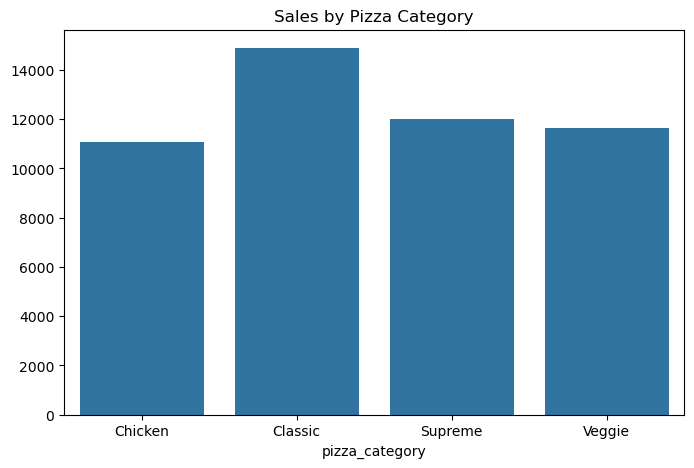

In [83]:
#CELL 15 — Sales by Category

category_sales = df.groupby("pizza_category")["quantity"].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.index, y=category_sales.values)

plt.title("Sales by Pizza Category")

plt.show()

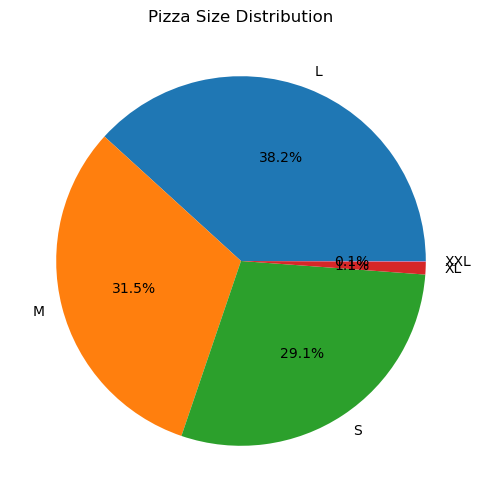

In [85]:
#CELL 16 — Sales by Pizza Size

size_sales = df.groupby("pizza_size")["quantity"].sum()

plt.figure(figsize=(6,6))

plt.pie(size_sales, labels=size_sales.index, autopct="%1.1f%%")

plt.title("Pizza Size Distribution")

plt.show()

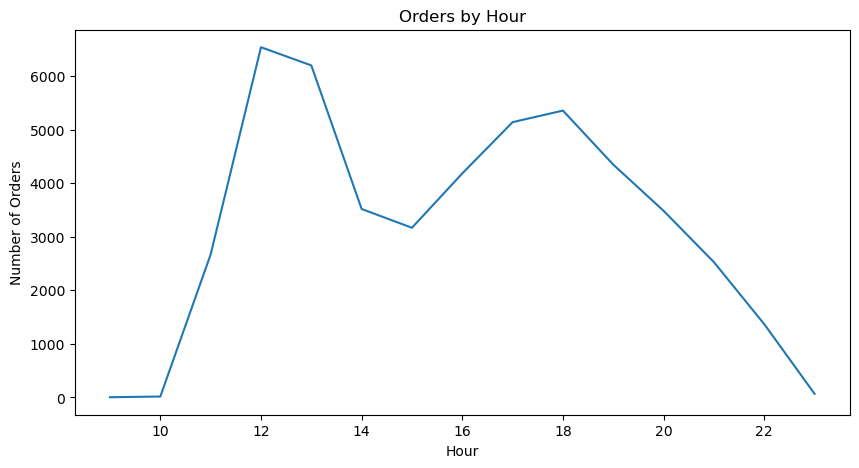

In [99]:
#CELL 17 — Orders by Hour

df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S")

df["order_time"].head()
df["hour"] = df["order_time"].dt.hour

hourly_orders = df.groupby("hour")["order_id"].count()

plt.figure(figsize=(10,5))

sns.lineplot(x=hourly_orders.index, y=hourly_orders.values)

plt.title("Orders by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Orders")

plt.show()

In [91]:
#CELL 18 — Orders by Day

df["day"] = df["order_date"].dt.day_name()

daily_orders = df.groupby("day")["order_id"].count()

plt.figure(figsize=(10,5))

sns.barplot(x=daily_orders.index, y=daily_orders.values)

plt.title("Orders by Day")

plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

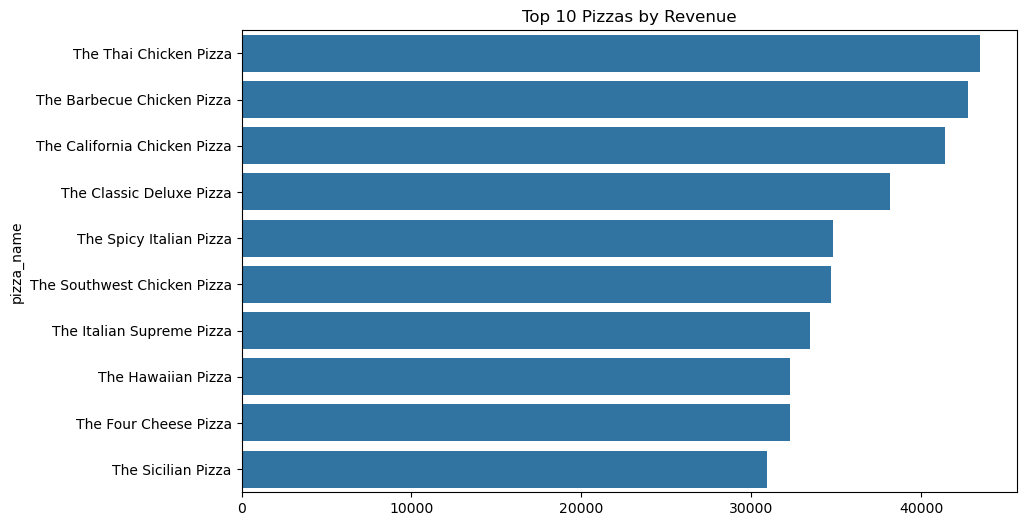

In [101]:
#CELL 19 — Top 10 Pizzas Visualization

top10 = df.groupby("pizza_name")["total_price"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Pizzas by Revenue")

plt.show()